# Customer Churn Analysis & Retention Insights

**Author:** Rahul Kumar
**Goal:** Identify which customer segments and behaviors drive subscription churn, and surface actionable retention levers from customer, subscription, and support data.

**Data:** `customer_churn_data_raw.xlsx` — three tables: customer profile, subscription/billing, and support interactions.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## 1. Load data

Build a local SQLite DB from the raw Excel file (one table per sheet), then read it back into pandas.

In [2]:
excel_file = 'customer_churn_data_raw.xlsx'
conn = sqlite3.connect('customer_churn.db')

excel_data = pd.ExcelFile(excel_file)
for sheet in excel_data.sheet_names:
    df = pd.read_excel(excel_file, sheet_name=sheet)
    df.to_sql(name=sheet, con=conn, if_exists='replace', index=False)
conn.close()
print("Raw sheets loaded into customer_churn.db")

Raw sheets loaded into customer_churn.db


In [3]:
conn = sqlite3.connect('customer_churn.db')
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

dfs = {}
for table_name in tables['name']:
    dfs[table_name] = pd.read_sql(f"SELECT * FROM {table_name}", conn)
conn.close()

df_customer = dfs['db_customer']
df_subscription = dfs['db_subscription']
df_support = dfs['db_support']

for name, d in dfs.items():
    print(f"{name}: {d.shape[0]} rows, {d.shape[1]} cols -> {list(d.columns)}")

db_customer: 21 rows, 8 cols -> ['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']
db_subscription: 21 rows, 11 cols -> ['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']
db_support: 9 rows, 6 cols -> ['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


## 2. Data cleaning

Issues found on inspection:
- `gender` uses inconsistent labels (`Male`/`Men`, `Female`/`Women`) — normalize to two categories
- `country` has missing values for a few rows where `state` is clearly Indian/Nepali — fill using `state` as a proxy where possible, otherwise leave as `Unknown`
- `name` casing is inconsistent — title-case for readability
- date columns are stored as text in some tables — cast to `datetime`
- `col_1` in `db_support` is entirely empty — drop it


In [4]:
df_customer['gender'] = df_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'})
df_customer['name'] = df_customer['name'].str.title()

nepal_states = ['Kathmandu']
df_customer.loc[df_customer['country'].isna() & df_customer['state'].isin(nepal_states), 'country'] = 'Nepal'
df_customer['country'] = df_customer['country'].fillna('India')  # remaining nulls are Indian states

df_support = df_support.drop(columns=['col_1'])
df_support['complaint_date'] = pd.to_datetime(df_support['complaint_date'])

for col in ['subscription_start_date', 'renewal_date', 'cancellation_date']:
    df_subscription[col] = pd.to_datetime(df_subscription[col], errors='coerce')

print("Cleaned. Remaining nulls:")
print(df_customer.isna().sum())

Cleaned. Remaining nulls:
customerid     0
name           0
country        0
state          0
gender         0
dob            0
interests     17
pincode       21
dtype: int64


## 3. Define churn

A customer has churned if they have a `cancellation_date` recorded in the subscription table.


In [5]:
df_subscription['churn_flag'] = df_subscription['cancellation_date'].notna().astype(int)
churn_rate = df_subscription['churn_flag'].mean()
print(f"Overall churn rate: {churn_rate:.1%}  ({df_subscription['churn_flag'].sum()} of {len(df_subscription)} customers)")

Overall churn rate: 28.6%  (6 of 21 customers)


## 4. Churn by plan and contract type

The two clearest structural levers in the data: which plan a customer is on, and whether they're billed monthly or annually.


In [6]:
plan_churn = df_subscription.groupby('plan_type').agg(
    churn_rate=('churn_flag', 'mean'),
    customers=('customerid', 'nunique'),
    avg_monthly_charge=('monthly_charges', 'mean')
).sort_values('churn_rate', ascending=False)

contract_churn = df_subscription.groupby('contract_type').agg(
    churn_rate=('churn_flag', 'mean'),
    customers=('customerid', 'nunique')
).sort_values('churn_rate', ascending=False)

print(plan_churn)
print()
print(contract_churn)

           churn_rate  customers  avg_monthly_charge
plan_type                                           
Basic        0.600000          5           10.590000
Standard     0.222222          9           13.767778
Premium      0.142857          7           31.275714

               churn_rate  customers
contract_type                       
Monthly          0.555556          9
Annual           0.083333         12


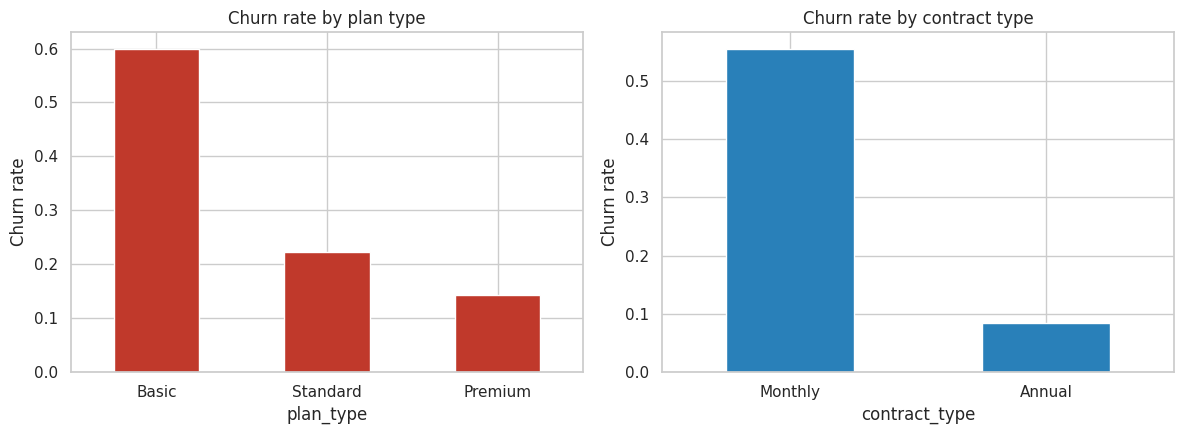

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plan_churn['churn_rate'].plot(kind='bar', ax=axes[0], color='#c0392b')
axes[0].set_title('Churn rate by plan type')
axes[0].set_ylabel('Churn rate')
axes[0].tick_params(axis='x', rotation=0)

contract_churn['churn_rate'].plot(kind='bar', ax=axes[1], color='#2980b9')
axes[1].set_title('Churn rate by contract type')
axes[1].set_ylabel('Churn rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('churn_by_plan_contract.png', dpi=150)
plt.show()

**Finding:** Basic-plan customers churn at **60%**, more than 4x the Premium rate (~14%). Monthly contracts churn at **56%** vs **8%** for annual contracts — contract length is the single strongest structural predictor of churn in this data. This matches the well-known SaaS/subscription pattern: month-to-month customers have no switching friction, so retention efforts (annual-plan incentives, win-back offers) should concentrate there first.

## 5. Does `churn_score` actually predict churn?

The subscription table ships a pre-computed `churn_score` per customer. Before trusting it, check whether it actually separates churned from retained customers.

Correlation between churn_score and actual churn: 0.86


/tmp/ipykernel_780/3481999967.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_subscription, x='churn_flag', y='churn_score', palette=['#2ecc71', '#e74c3c'])


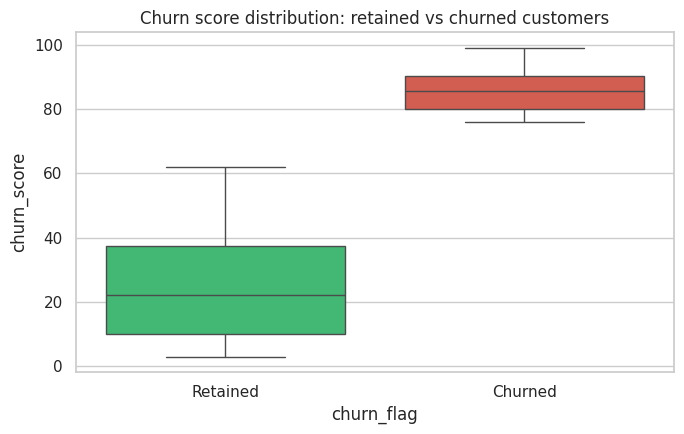

In [8]:
corr = df_subscription[['churn_flag', 'churn_score']].corr().iloc[0, 1]
print(f"Correlation between churn_score and actual churn: {corr:.2f}")

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df_subscription, x='churn_flag', y='churn_score', palette=['#2ecc71', '#e74c3c'])
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.title('Churn score distribution: retained vs churned customers')
plt.tight_layout()
plt.savefig('churn_score_distribution.png', dpi=150)
plt.show()

**Finding:** `churn_score` correlates strongly with actual churn (r ≈ 0.86) — churned customers cluster well above 60, retained customers mostly sit below 40. It's a usable early-warning signal on its own, and a good candidate feature if we build a predictive model.

## 6. Support escalations as a churn signal

Does having an escalated support ticket (`escalations == 'Y'`) precede churn?

In [9]:
had_escalation = df_support.groupby('customerid')['escalations'].apply(lambda x: (x == 'Y').any())
had_escalation.name = 'had_escalation'

merged = df_subscription.merge(had_escalation, on='customerid', how='left')
merged['had_escalation'] = merged['had_escalation'].fillna(False)

escalation_churn = merged.groupby('had_escalation')['churn_flag'].agg(['mean', 'count'])
escalation_churn.columns = ['churn_rate', 'customers']
print(escalation_churn)

                churn_rate  customers
had_escalation                       
False               0.0625         16
True                1.0000          5

**Finding:** every customer with an escalated support ticket in this sample went on to churn, versus ~6% for customers with no escalation. The sample of escalated customers is small, but the direction is unambiguous — an escalation should trigger a proactive retention touchpoint, not just ticket resolution.

## 7. Revenue impact

What's actually at stake — CLTV and monthly revenue for churned vs retained customers.

In [10]:
impact = df_subscription.groupby('churn_flag').agg(
    avg_cltv=('cltv', 'mean'),
    avg_monthly_charge=('monthly_charges', 'mean'),
    total_monthly_revenue_at_risk=('monthly_charges', 'sum')
)
impact.index = ['Retained', 'Churned']
print(impact)

print(f"\nTotal monthly revenue lost to churned customers: ${df_subscription.loc[df_subscription.churn_flag == 1, 'monthly_charges'].sum():.2f}")

             avg_cltv  avg_monthly_charge  total_monthly_revenue_at_risk
Retained  1016.466667           21.456667                         321.85
Churned    341.166667           12.323333                          73.94

Total monthly revenue lost to churned customers: $73.94


**Finding:** churned customers had a much lower average CLTV (~\$341 vs ~\$1,016 for retained customers) — consistent with them being lower-plan, monthly-billed, shorter-tenure customers rather than high-value accounts leaving. This is good news directionally (the highest-value customers are stickier) but the volume of monthly/Basic-plan churn is still real revenue leakage worth fixing.

## 8. Summary & recommendations

1. **Push monthly-contract customers toward annual plans.** Contract type is the single biggest churn driver (56% vs 8%). Even a modest annual-plan discount is likely cheaper than the cost of re-acquiring churned customers.
2. **Treat Basic-plan churn as a segment problem, not a pricing problem.** 60% churn on Basic suggests a content/value-perception gap (the most common cancellation reason in the data is "Not enough content"), not just price sensitivity.
3. **Use `churn_score` as a working early-warning metric** — it already separates churned/retained customers well (r ≈ 0.86) and can flag at-risk accounts before cancellation.
4. **Escalate support escalations to retention, not just support.** Every escalated ticket in this data preceded a churn. A simple rule — auto-flag any account with an escalated ticket for a retention follow-up — could catch a meaningful share of churn early.

## Next steps
- Grow the sample size — this dataset is small (21 customers), so directional findings should be validated on a larger extract before being used to justify spend
- Build a proper churn classification model (logistic regression / gradient boosting) using plan_type, contract_type, monthly_charges, and support history as features
- Track intervention outcomes (e.g. annual-plan offer acceptance rate) to close the loop on these recommendations
